In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn

In [2]:
# Parameters
m = 1.0
c = 0.4
k = 4.0

# Initial conditions
x0 = 1.0
v0 = 0.0

# Time interval
t_start = 0.0
t_end = 10.0

In [3]:
def system(t, y):
    x, v = y
    dxdt = v
    dvdt = -(c/m) * v - (k/m) * x
    return [dxdt, dvdt]

t_eval = np.linspace(t_start, t_end, 500)

reference = solve_ivp(
    fun=system,
    t_span=(t_start, t_end),
    y0=[x0, v0],
    t_eval=t_eval,
    method='RK45'
)

t_ref = reference.t
x_ref = reference.y[0]

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)

In [5]:
# Collocation points for physics loss
t_train = torch.linspace(t_start, t_end, 200).view(-1, 1)
t_train = t_train.requires_grad_(True)

# Initial condition point
t0 = torch.tensor([[0.0]], requires_grad=True)

# Exact initial values
x0_tensor = torch.tensor([[x0]], dtype=torch.float32)
v0_tensor = torch.tensor([[v0]], dtype=torch.float32)

In [6]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
loss_history = []

for epoch in range(5000):
    optimizer.zero_grad()

    # Network prediction
    x_pred = model(t_train)

    # First derivative dx/dt
    dx_dt = torch.autograd.grad(
        x_pred, t_train,
        grad_outputs=torch.ones_like(x_pred),
        create_graph=True
    )[0]

    # Second derivative d2x/dt2
    d2x_dt2 = torch.autograd.grad(
        dx_dt, t_train,
        grad_outputs=torch.ones_like(dx_dt),
        create_graph=True
    )[0]

    # Physics residual: x'' + (c/m)x' + (k/m)x = 0
    residual = d2x_dt2 + (c/m) * dx_dt + (k/m) * x_pred
    physics_loss = torch.mean(residual**2)

    # Initial condition for x(0)
    x0_pred = model(t0)
    ic_x_loss = torch.mean((x0_pred - x0_tensor)**2)

    # Initial condition for x'(0)
    dx0_dt = torch.autograd.grad(
        x0_pred, t0,
        grad_outputs=torch.ones_like(x0_pred),
        create_graph=True
    )[0]
    ic_v_loss = torch.mean((dx0_dt - v0_tensor)**2)

    # Total loss
    loss = physics_loss + ic_x_loss + ic_v_loss

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.8f}")

Epoch 0, Loss = 3.60942435
Epoch 500, Loss = 0.17830072
Epoch 1000, Loss = 0.09715766
Epoch 1500, Loss = 0.07551219
Epoch 2000, Loss = 0.05932460
Epoch 2500, Loss = 0.04887899
Epoch 3000, Loss = 0.04222934
Epoch 3500, Loss = 0.03777082
Epoch 4000, Loss = 0.03525473
Epoch 4500, Loss = 0.03365006


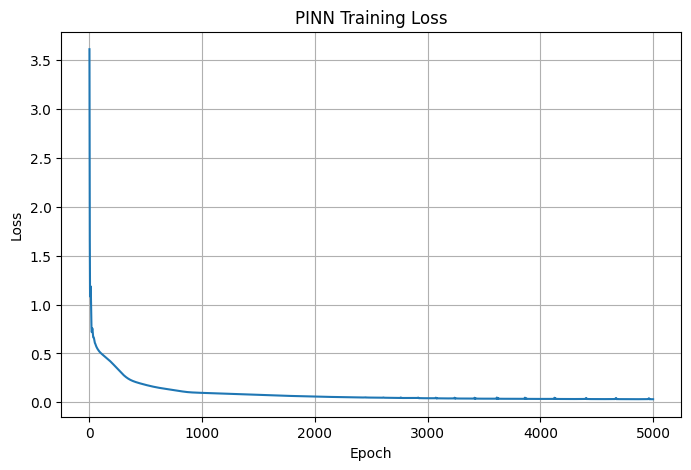

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PINN Training Loss')
plt.grid(True)
plt.show()

In [9]:
t_test = torch.tensor(t_ref.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    x_pinn = model(t_test).numpy().flatten()

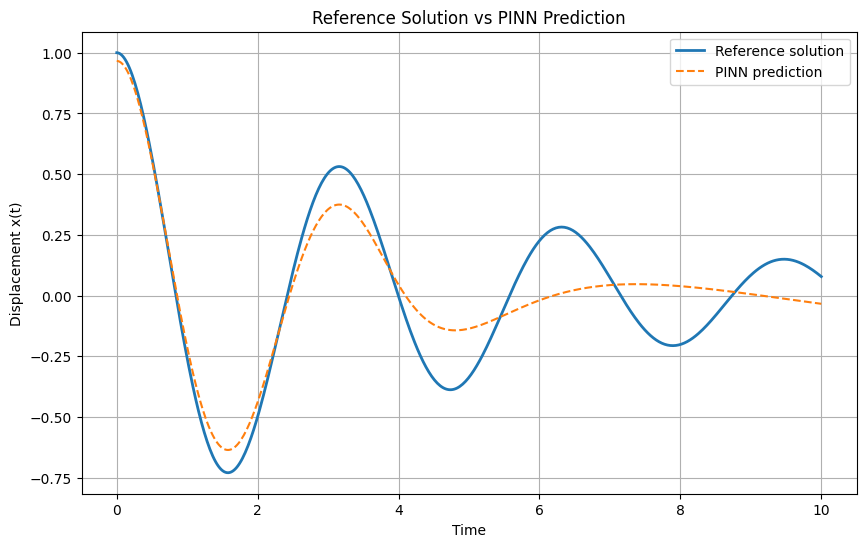

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(t_ref, x_ref, label='Reference solution', linewidth=2)
plt.plot(t_ref, x_pinn, '--', label='PINN prediction')
plt.xlabel('Time')
plt.ylabel('Displacement x(t)')
plt.title('Reference Solution vs PINN Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
pinn_mse = np.mean((x_ref - x_pinn)**2)
print("PINN MSE:", pinn_mse)

PINN MSE: 0.020613424608902194


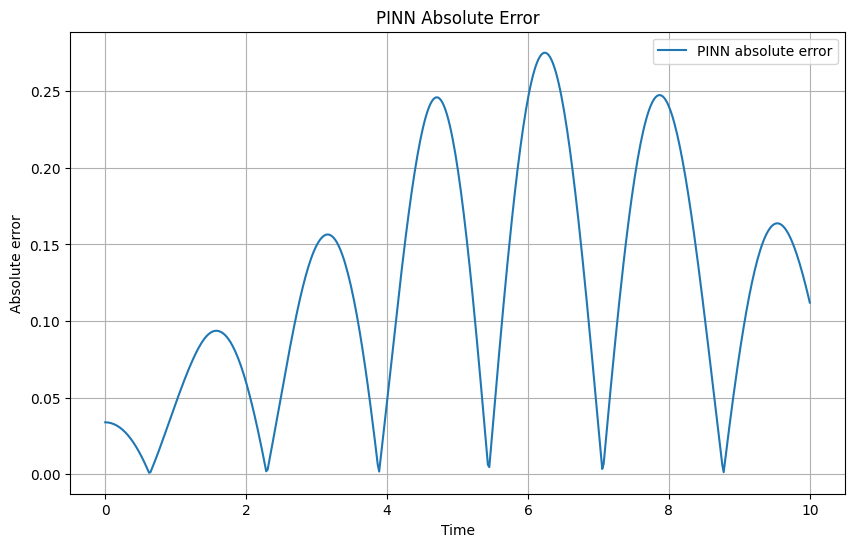

In [12]:
pinn_error = np.abs(x_ref - x_pinn)

plt.figure(figsize=(10, 6))
plt.plot(t_ref, pinn_error, label='PINN absolute error')
plt.xlabel('Time')
plt.ylabel('Absolute error')
plt.title('PINN Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

The PINN is able to learn the overall behavior of the damped harmonic oscillator using only the governing equation and the initial conditions.

Its prediction follows the reference solution reasonably well, although the accuracy may still be lower than RK4 for this simple problem.

This shows that PINNs are flexible and physically informed, but they may require more training effort than classical numerical solvers.